In [2]:
import os
import pandas as pd

# Path to local directory (adjust as needed)
directory = "C:/Users/ptboe/vscode/VU/Bootstrapping-Thesis/results/gaussian/strong/modified"

# Step 1: Collect summary files
summary_files = [f for f in os.listdir(directory) if f.startswith("summary_lambda") and f.endswith(".csv")]

# Step 2: Read all summaries with lambda/alpha extraction
records = []
for filename in summary_files:
    filepath = os.path.join(directory, filename)
    df = pd.read_csv(filepath)
    lam = float(filename.split("lambda")[1].split("_")[0])
    alpha = float(filename.split("alpha")[1].replace(".csv", ""))
    row = df.iloc[0].copy()
    row["lambda"] = lam
    row["alpha"] = alpha
    records.append(row)

summary_df = pd.DataFrame(records)

# Step 3: Pivot into 2D tables (lambda x alpha) for each metric
metrics = [
    "coverage_support", "coverage_null", "ci_width_support",
    "mean_abs_bias", "precision", "recall", "fdr", "jaccard", "snr"
]

pivot_tables = {
    metric: summary_df.pivot(index="lambda", columns="alpha", values=metric)
    for metric in metrics
}

# Step 4: Export each table to CSV
output_dir = os.path.join(directory, "tables")
os.makedirs(output_dir, exist_ok=True)

for metric, table in pivot_tables.items():
    csv_path = os.path.join(output_dir, f"{metric}_table.csv")
    table.to_csv(csv_path, float_format="%.4f")
    print(f"Saved: {csv_path}")


# display the results of the dataframes
for metric, table in pivot_tables.items():
    print(f"\n{metric} Table:")
    print(table)
    print("\n")

Saved: C:/Users/ptboe/vscode/VU/Bootstrapping-Thesis/results/gaussian/strong/modified\tables\coverage_support_table.csv
Saved: C:/Users/ptboe/vscode/VU/Bootstrapping-Thesis/results/gaussian/strong/modified\tables\coverage_null_table.csv
Saved: C:/Users/ptboe/vscode/VU/Bootstrapping-Thesis/results/gaussian/strong/modified\tables\ci_width_support_table.csv
Saved: C:/Users/ptboe/vscode/VU/Bootstrapping-Thesis/results/gaussian/strong/modified\tables\mean_abs_bias_table.csv
Saved: C:/Users/ptboe/vscode/VU/Bootstrapping-Thesis/results/gaussian/strong/modified\tables\precision_table.csv
Saved: C:/Users/ptboe/vscode/VU/Bootstrapping-Thesis/results/gaussian/strong/modified\tables\recall_table.csv
Saved: C:/Users/ptboe/vscode/VU/Bootstrapping-Thesis/results/gaussian/strong/modified\tables\fdr_table.csv
Saved: C:/Users/ptboe/vscode/VU/Bootstrapping-Thesis/results/gaussian/strong/modified\tables\jaccard_table.csv
Saved: C:/Users/ptboe/vscode/VU/Bootstrapping-Thesis/results/gaussian/strong/modified

In [7]:
import os
import pandas as pd
import numpy as np

# 1. Load all summaries for a given error/signal/method folder
def load_summary_tables(directory):
    summary_files = [f for f in os.listdir(directory) if f.startswith("summary_lambda") and f.endswith(".csv")]
    records = []
    for filename in summary_files:
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath)
        lam = float(filename.split("lambda")[1].split("_")[0])
        alpha = float(filename.split("alpha")[1].replace(".csv", ""))
        row = df.iloc[0].copy()
        row["lambda"] = lam
        row["alpha"] = alpha
        records.append(row)
    return pd.DataFrame(records)


# 2. Compute tail asymmetry per tracked file
def compute_tail_asymmetry(tracked_dir, j_indices):
    tail_data = []
    for j in j_indices:
        tracked_files = [f for f in os.listdir(tracked_dir) if f.startswith(f"tracked_j{j}_")]
        for f in tracked_files:
            path = os.path.join(tracked_dir, f)
            df = pd.read_csv(path)
            lam = float(f.split("lambda")[1].split("_")[0])
            alpha = float(f.split("alpha")[1].replace(".csv", ""))
            mean_asym = df["tail_asym"].mean()
            tail_data.append({"lambda": lam, "alpha": alpha, f"tail_asym_j{j}": mean_asym})
    return pd.DataFrame(tail_data)


# 3. Compute pivot tables (lambda x alpha)
def generate_metric_pivots(summary_df, tracked_df=None, metrics=None):
    if metrics is None:
        metrics = [
            "coverage_support", "coverage_null", "ci_width_support",
            "mean_abs_bias", "precision", "recall", "fdr", "jaccard", "snr"
        ]
    
    pivot_tables = {
        metric: summary_df.pivot(index="lambda", columns="alpha", values=metric)
        for metric in metrics
    }

    # Merge in tracked tail asymmetry if present
    if tracked_df is not None:
        tail_asym_cols = [col for col in tracked_df.columns if col.startswith("tail_asym")]
        for col in tail_asym_cols:
            pivot_tables[col] = tracked_df.pivot(index="lambda", columns="alpha", values=col)

    return pivot_tables


# 4. Generate comparison table across 4 methods
def load_summary_across_methods(base_path, error_type, signal_type, metric):
    method_dfs = []
    for method in ["modified", "wild", "naive", "block"]:
        method_dir = os.path.join(base_path, error_type, signal_type, method)
        summary_df = load_summary_tables(method_dir)
        summary_df = summary_df[["lambda", "alpha", metric]].copy()
        summary_df["method"] = method
        method_dfs.append(summary_df)

    all_df = pd.concat(method_dfs, ignore_index=True)
    pivot = all_df.pivot_table(index=["lambda", "alpha"], columns="method", values=metric)
    return pivot.reset_index()


summary_df = load_summary_tables("results/gaussian/strong/modified")
tracked_df = compute_tail_asymmetry("results/gaussian/strong/modified", [5, 22])
pivots = generate_metric_pivots(summary_df, tracked_df)

ValueError: Index contains duplicate entries, cannot reshape

In [8]:
import os
import pandas as pd

# Updated function to load and pivot metrics across 4 methods
def load_and_pivot_all_methods(base_path, error_type, signal_type, metric):
    records = []
    for method in ["modified", "wild", "naive", "block"]:
        method_dir = os.path.join(base_path, error_type, signal_type, method)
        files = [f for f in os.listdir(method_dir) if f.startswith("summary_lambda") and f.endswith(".csv")]
        for f in files:
            lam = float(f.split("lambda")[1].split("_")[0])
            alpha = float(f.split("alpha")[1].replace(".csv", ""))
            df = pd.read_csv(os.path.join(method_dir, f))
            val = df.iloc[0][metric]
            records.append({"lambda": lam, "alpha": alpha, "method": method, metric: val})
    
    full_df = pd.DataFrame(records)
    pivot_df = full_df.pivot_table(index="lambda", columns=["alpha", "method"], values=metric)
    return pivot_df.reset_index()

# Example usage
example_metric = "coverage_support"
pivot_df = load_and_pivot_all_methods("results", "gaussian", "strong", example_metric)
pivot_df.head()


alpha   lambda 0.099                      0.199                      0.398  \
method         block modified naive  wild block modified naive  wild block   
0       0.0656  0.20     0.20  0.22  0.22  0.20     0.20  0.22  0.22  0.20   
1       0.1312  0.18     0.16  0.16  0.16  0.18     0.16  0.16  0.22  0.18   
2       0.2625  0.04     0.06  0.06  0.06  0.04     0.06  0.06  0.06  0.04   

alpha                        
method modified naive  wild  
0          0.20  0.22  0.22  
1          0.16  0.16  0.22  
2          0.06  0.06  0.06

In [ ]:
def clean_grouped_pivot(base_path, error_type, signal_type, metric, alphas=[0.099, 0.199]):
    method_blocks = []
    for method in ["naive", "modified", "wild", "block"]:
        method_dir = os.path.join(base_path, error_type, signal_type, method)
        if not os.path.exists(method_dir):
            continue

        rows = []
        files = [f for f in os.listdir(method_dir) if f.startswith("summary_lambda")]
        for f in files:
            lam = float(f.split("lambda")[1].split("_")[0])
            alpha = float(f.split("alpha")[1].replace(".csv", ""))
            if round(alpha, 3) not in alphas:
                continue
            val = pd.read_csv(os.path.join(method_dir, f)).iloc[0][metric]
            rows.append({"lambda": lam, "alpha": round(alpha, 3), metric: val})
        
        df = pd.DataFrame(rows)
        pivot = df.pivot(index="lambda", columns="alpha", values=metric)
        pivot.columns = [f"{method}_α={a}" for a in pivot.columns]
        method_blocks.append(pivot)

    grouped = pd.concat(method_blocks, axis=1).sort_index()
    return grouped.reset_index()

grouped_cov = clean_grouped_pivot("results", "gaussian", "strong", "boot_var_support")

# Example usage of the grouped pivot
print(grouped_cov)


   lambda  naive_α=0.099  naive_α=0.199  modified_α=0.099  modified_α=0.199  \
0  0.0656           0.22           0.22              0.20              0.20   
1  0.1312           0.16           0.16              0.16              0.16   
2  0.2625           0.06           0.06              0.06              0.06   

   wild_α=0.099  wild_α=0.199  block_α=0.099  block_α=0.199  
0          0.22          0.22           0.20           0.20  
1          0.16          0.22           0.18           0.18  
2          0.06          0.06           0.04           0.04  


In [11]:
import os
import pandas as pd

# Final visualization structure: 4 separate 3x3 tables (lambda × alpha) for each method

def load_3x3_grids_per_method(base_path, error_type, signal_type, metric):
    method_grids = {}

    for method in ["naive", "modified", "wild", "block"]:
        method_dir = os.path.join(base_path, error_type, signal_type, method)
        if not os.path.exists(method_dir):
            continue

        records = []
        summary_files = [f for f in os.listdir(method_dir) if f.startswith("summary_lambda") and f.endswith(".csv")]
        for f in summary_files:
            lam = float(f.split("lambda")[1].split("_")[0])
            alpha = float(f.split("alpha")[1].replace(".csv", ""))
            val = pd.read_csv(os.path.join(method_dir, f)).iloc[0][metric]
            records.append({"lambda": lam, "alpha": alpha, metric: val})

        df = pd.DataFrame(records)
        pivot = df.pivot(index="lambda", columns="alpha", values=metric)
        method_grids[method] = pivot.sort_index(axis=0).sort_index(axis=1)

    return method_grids

        # summary = {
        #     "method": self.method,
        #     "lambda_val": self.lambda_val,
        #     "threshold_val": self.threshold_val,
        #     "signal_type": self.signal_type,
        #     "error_type": self.error_type,
        #     "coverage_support": avg("coverage_rate_support"),
        #     "coverage_null": avg("null_coverage_rate"),
        #     "ci_width_support": avg("avg_ci_width_support"),
        #     "mean_abs_bias": avg("mean_abs_bias_support"),
        #     "precision": avg("precision"),
        #     "recall": avg("recall"),
        #     "fdr": avg("fdr"),
        #     "jaccard": avg("jaccard"),
        #     "snr": avg("snr"),
        #     "boot_var_support": np.mean(boot_var_acc),
        #     "boot_bias_support": np.mean(boot_bias_acc),
        #     "tail_asym_support": np.mean(tail_asym_acc)
        # }

# Example usage:
# mean_abs_bias
# coverage_support
# ci_width_support
results = load_3x3_grids_per_method("results", "ar1", "weak", "fdr")
for method, grid in results.items():
    print(f"\n=== {method.upper()} ===")
    print(grid.round(3))



=== NAIVE ===
alpha   0.173  0.346  0.692
lambda                     
0.0747  0.818  0.818  0.819
0.1495  0.467  0.474  0.466
0.2990  0.040  0.045  0.042

=== MODIFIED ===
alpha   0.173  0.346  0.692
lambda                     
0.0747  0.819  0.817  0.820
0.1495  0.468  0.464  0.465
0.2990  0.047  0.041  0.043

=== WILD ===
alpha   0.173  0.346  0.692
lambda                     
0.0747  0.818  0.818  0.818
0.1495  0.468  0.466  0.471
0.2990  0.038  0.045  0.042

=== BLOCK ===
alpha   0.173  0.346  0.692
lambda                     
0.0747  0.819  0.818  0.820
0.1495  0.473  0.469  0.467
0.2990  0.043  0.037  0.040


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def load_dim_sensitivity_metrics(base_path="results/dim_sensitivity"):
    metrics = ["coverage_support", "ci_width_support"]
    results = {method: [] for method in ["naive", "modified", "wild", "block"]}

    for method in results:
        method_dir = os.path.join(base_path, method)
        if not os.path.isdir(method_dir):
            continue

        for sub in os.listdir(method_dir):
            if not sub.startswith("p"):
                continue

            p = int(sub[1:])
            n = 250  # fixed in your design
            pn_ratio = round(p / n, 3)

            summary_files = [f for f in os.listdir(os.path.join(method_dir, sub)) if f.startswith("summary_")]
            if not summary_files:
                continue

            summary_path = os.path.join(method_dir, sub, summary_files[0])
            df = pd.read_csv(summary_path)
            row = {"p": p, "p/n": pn_ratio}
            for m in metrics:
                row[m] = df.iloc[0][m]
            results[method].append(row)

    # Convert to DataFrames
    for method in results:
        results[method] = pd.DataFrame(results[method]).sort_values(by="p")
    
    return results


In [5]:
def plot_metric_vs_pn(results_dict, metric, ylabel, title):
    plt.figure(figsize=(8, 5))
    for method, df in results_dict.items():
        plt.plot(df["p/n"], df[metric], marker='o', label=method)

    plt.axvline(x=0.04, linestyle='--', color='gray', label="CL-paper 1/25 ratio")
    plt.xlabel("p / n")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"results/dim_sens_figs/strong_ar1_{metric}_vs_pn.png")
    plt.show()

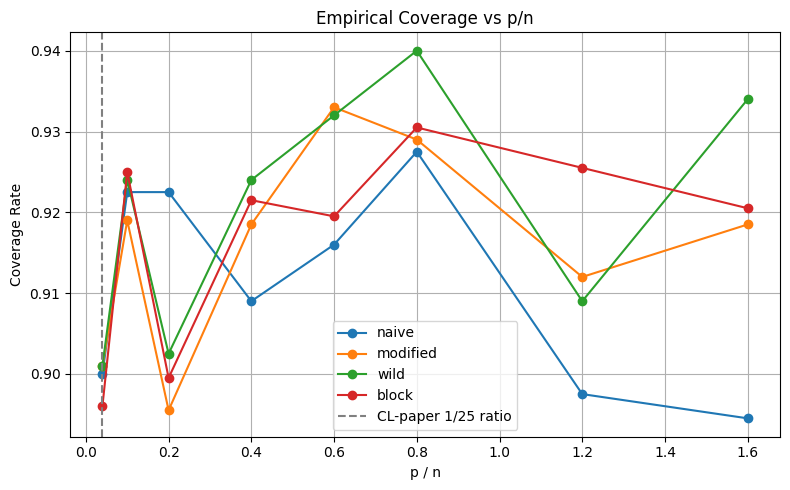

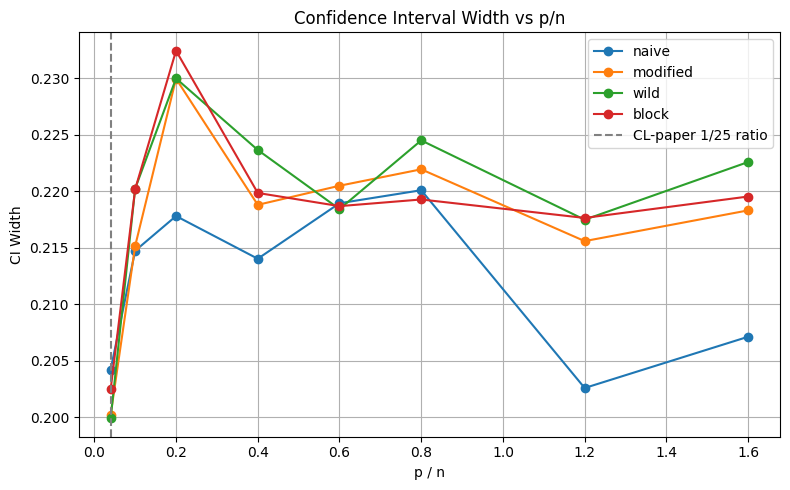

In [6]:
results = load_dim_sensitivity_metrics()

plot_metric_vs_pn(results, "coverage_support", ylabel="Coverage Rate", title="Empirical Coverage vs p/n")
plot_metric_vs_pn(results, "ci_width_support", ylabel="CI Width", title="Confidence Interval Width vs p/n")


In [11]:
import pandas as pd
import numpy as np
import os
from config import Config
from dgp import DGP
from simulation import SingleSimulationRun
from MonteCarloRunner import MonteCarloRunner
from ParralelSimulation import compute_lambda_alpha 

def debug_dim_sensitivity_run(p, method="naive", alpha_th=0.25, lambda0=1.0, signal_type="strong", error_type="gaussian", base_dir="results/dim_sensitivity"):
    print(f"\n=== DEBUGGING p={p}, method={method} ===")
    config = Config(p=p, n=250)
    print(f"Support size (s): {config.s}")
    print(f"Support indices: {config.support}")
    print(f"Signal vector: {config.signal_vectors[signal_type][:config.s]}")
    print(f"Threshold (α): {config.get_threshold(alpha_th):.5f}")

    dgp = DGP(config=config, signal_type=signal_type, error_type=error_type)
    dgp_data = dgp.generate()
    beta_true = dgp_data["beta"]
    print(f"Non-zero entries in beta_true: {np.nonzero(beta_true)[0].tolist()}")
    print(f"beta_true values: {beta_true[config.support]}")
    print(f"SNR: {dgp_data['snr']:.2f}")
    lambda_val, alpha_val = compute_lambda_alpha(config, signal_type=signal_type, error_type=error_type)
    print(f"Lambda (λ): {lambda_val:.5f}")
    print(f"Threshold (α): {alpha_val:.5f}")

    # Single run
    sim = SingleSimulationRun(
        method=method,
        lambda_val=lambda_val,
        threshold_val=config.get_threshold(alpha_th),
        signal_type=signal_type,
        error_type=error_type,
        config=config,
        level=0.90,
        tracked_indices=config.support
    )
    result = sim.run()

    print(f"\n→ Coverage vector over support: {result['coverage'][config.support]}")
    print(f"→ Mean coverage on support: {result['coverage_rate_support']:.3f}")
    print(f"→ CI widths on support: {result['ci_length'][config.support]}")
    print(f"→ Mean CI width on support: {result['avg_ci_width_support']:.3f}")

    print(f"→ Null coverage rate: {result['null_coverage_rate']:.3f}")
    print(f"→ β̂ bias: {result['bias_hat'][config.support]}")
    print(f"→ Bootstrap variance on support: {result['boot_var'][config.support]}")
    print(f"→ Bootstrap bias: {result['boot_bias'][config.support]}")
    print(f"→ Jaccard: {result['jaccard']:.3f}, Precision: {result['precision']:.3f}, Recall: {result['recall']:.3f}")
    print(f"→ β̂: {result['beta_hat'][config.support]}")
    print(f"→ β̃ (thresholded): {result['beta_tilde'][config.support]}")

    # Check summary file if it exists
    method_dir = os.path.join(base_dir, method, f"p{p}")
    if os.path.isdir(method_dir):
        files = [f for f in os.listdir(method_dir) if f.startswith("summary_")]
        if files:
            summary_file = os.path.join(method_dir, files[0])
            print(f"\n🔍 Found saved summary file: {summary_file}")
            df = pd.read_csv(summary_file)
            print(df.T)
        else:
            print("\n⚠ No summary CSV found in expected dir.")
    else:
        print("\n⚠ Method directory not found.")


In [12]:
debug_dim_sensitivity_run(p=10, method="naive")


=== DEBUGGING p=10, method=naive ===
Support size (s): 5
Support indices: [0, 1, 2, 3, 4]
Signal vector: [ 5 -4 10 -6  2]
Threshold (α): 0.02399
Non-zero entries in beta_true: [0, 1, 2, 3, 4]
beta_true values: [ 5. -4. 10. -6.  2.]
SNR: 192.08
Lambda (λ): 0.09578
Threshold (α): 0.53073
Running simulation with seed: 42

→ Coverage vector over support: [ True  True  True  True  True]
→ Mean coverage on support: 1.000
→ CI widths on support: [0.20620862 0.20647652 0.21809401 0.19989623 0.20368899]
→ Mean CI width on support: 0.207
→ Null coverage rate: 0.800
→ β̂ bias: [-0.16718686  0.05177271  0.00104423  0.00566295 -0.11893547]
→ Bootstrap variance on support: [0.00425943 0.00423856 0.00431936 0.00404282 0.00426787]
→ Bootstrap bias: [-0.09995798  0.11205749 -0.0715241   0.09634748 -0.09410577]
→ Jaccard: 0.833, Precision: 0.833, Recall: 1.000
→ β̂: [ 4.83281314 -3.94822729 10.00104423 -5.99433705  1.88106453]
→ β̃ (thresholded): [ 4.83281314 -3.94822729 10.00104423 -5.99433705  1.8810

In [13]:
debug_dim_sensitivity_run(p=10, method="modified")


=== DEBUGGING p=10, method=modified ===
Support size (s): 5
Support indices: [0, 1, 2, 3, 4]
Signal vector: [ 5 -4 10 -6  2]
Threshold (α): 0.02399
Non-zero entries in beta_true: [0, 1, 2, 3, 4]
beta_true values: [ 5. -4. 10. -6.  2.]
SNR: 192.08
Lambda (λ): 0.09578
Threshold (α): 0.53073
Running simulation with seed: 42

[MODIFIED BOOTSTRAP DIAGNOSTICS]

--- j = 0 ---
β_true[0]: 5.0000
CI: [4.8281, 5.0338]
→ Contains β_true? YES
→ β̂ bias: -0.1672
→ Bootstrap mean: 4.7326
→ Bootstrap std: 0.06528
→ CI width: 0.2056

--- j = 1 ---
β_true[1]: -4.0000
CI: [-4.1587, -3.9520]
→ Contains β_true? YES
→ β̂ bias: 0.0518
→ Bootstrap mean: -3.8365
→ Bootstrap std: 0.06512
→ CI width: 0.2067

--- j = 2 ---
β_true[2]: 10.0000
CI: [9.9639, 10.1818]
→ Contains β_true? YES
→ β̂ bias: 0.0010
→ Bootstrap mean: 9.9296
→ Bootstrap std: 0.06574
→ CI width: 0.2179

--- j = 3 ---
β_true[3]: -6.0000
CI: [-6.1938, -5.9938]
→ Contains β_true? YES
→ β̂ bias: 0.0057
→ Bootstrap mean: -5.8979
→ Bootstrap std: 0.

In [31]:
debug_dim_sensitivity_run(p=10, method="naive")


=== DEBUGGING p=10, method=naive ===
Support size (s): 5
Support indices: [0, 1, 2, 3, 4]
Signal vector: [ 5 -4 10 -6  2]
Threshold (α): 0.02399
Non-zero entries in beta_true: [0, 1, 2, 3, 4]
beta_true values: [ 5. -4. 10. -6.  2.]
SNR: 182.68
Lambda (λ): 0.09578
Threshold (α): 0.53074
Running simulation with seed: 42

→ Coverage vector over support: [False  True False False False]
→ Mean coverage on support: 0.200
→ CI widths on support: [0.20520304 0.17277237 0.13680144 0.15426118 0.18740939]
→ Mean CI width on support: 0.171
→ Null coverage rate: 1.000
→ β̂ bias: [-0.6274971  -0.21891354 -0.2276961   0.11535237 -0.09872289]
→ Bootstrap variance on support: [0.00512601 0.00353736 0.00290816 0.00251755 0.00437669]
→ Bootstrap bias: [-0.09622965  0.12646204 -0.08099204  0.11635981 -0.10471139]
→ Jaccard: 0.833, Precision: 0.833, Recall: 1.000
→ β̂: [ 4.3725029  -4.21891354  9.7723039  -5.88464763  1.90127711]
→ β̃ (thresholded): [ 4.3725029  -4.21891354  9.7723039  -5.88464763  1.9012

In [66]:
import os
import pandas as pd

# Final visualization structure: 4 separate 3×3 tables (λ × α) for each method
def load_3x3_grids_per_method(base_path, error_type, signal_type, metric, p=300):
    method_grids = {}
    methods = ["naive", "modified", "wild", "block"]

    for method in methods:
        method_base = os.path.join(base_path, error_type, signal_type, method)
        method_dir  = os.path.join(method_base, f"p{p}")
        if not os.path.isdir(method_dir):
            continue

        records = []
        for fname in os.listdir(method_dir):
            if not fname.startswith("summary_lambda") or not fname.endswith(".csv"):
                continue

            lam_str   = fname.split("lambda")[1].split("_")[0]
            alpha_str = fname.split("alpha")[1].replace(".csv", "")
            lam, alpha = float(lam_str), float(alpha_str)

            val = pd.read_csv(os.path.join(method_dir, fname)).iloc[0][metric]
            records.append({"lambda": lam, "alpha": alpha, metric: val})

        if not records:
            continue

        df = pd.DataFrame(records)
        pivot = df.pivot(index="lambda", columns="alpha", values=metric)
        # sort so rows/cols in increasing order
        pivot = pivot.sort_index(axis=0).sort_index(axis=1)
        # **round all values to 3 decimals**
        pivot = pivot.round(3)

        method_grids[method] = pivot

    return method_grids

        # summary = {
        #     "method": self.method,
        #     "lambda_val": self.lambda_val,
        #     "threshold_val": self.threshold_val,
        #     "signal_type": self.signal_type,
        #     "error_type": self.error_type,
        #     "coverage_support": avg("coverage_rate_support"),
        #     "coverage_null": avg("null_coverage_rate"),
        #     "ci_width_support": avg("avg_ci_width_support"),
        #     "mean_abs_bias": avg("mean_abs_bias_support"),
        #     "precision": avg("precision"),
        #     "recall": avg("recall"),
        #     "fdr": avg("fdr"),
        #     "jaccard": avg("jaccard"),
        #     "snr": avg("snr"),
        #     "boot_var_support": np.mean(boot_var_acc),
        #     "boot_bias_support": np.mean(boot_bias_acc),
        #     "tail_asym_support": np.mean(tail_asym_acc)
        # }




# Example usage:
grids = load_3x3_grids_per_method(
    base_path="results/symmetric_sweep",
    error_type="ar1",
    signal_type="nearzero",
    metric="fdr",
    p=300
)

for method, grid in grids.items():
    print(f"\n=== {method.upper()} ===")
    print(grid)



=== NAIVE ===
alpha    0.058  0.117  0.124  0.233  0.247  0.494
lambda                                           
0.06367  0.842  0.862    NaN  0.892    NaN    NaN
0.06675    NaN    NaN  0.860    NaN  0.860  0.861
0.12733  0.704  0.696    NaN  0.741    NaN    NaN
0.13350    NaN    NaN  0.600    NaN  0.604  0.600
0.25466  0.000  0.000    NaN  0.364    NaN    NaN
0.26700    NaN    NaN  0.057    NaN  0.054  0.052

=== MODIFIED ===
alpha    0.058  0.117  0.124  0.233  0.247  0.494
lambda                                           
0.06367  0.853  0.860    NaN  0.883    NaN    NaN
0.06675    NaN    NaN  0.862    NaN  0.861  0.862
0.12733  0.588  0.731    NaN  0.650    NaN    NaN
0.13350    NaN    NaN  0.606    NaN  0.607  0.597
0.25466  0.000  0.222    NaN  0.143    NaN    NaN
0.26700    NaN    NaN  0.054    NaN  0.054  0.056

=== WILD ===
alpha    0.058  0.117  0.124  0.233  0.247  0.494
lambda                                           
0.06367  0.841  0.810    NaN  0.827    NaN    NaN
0.0

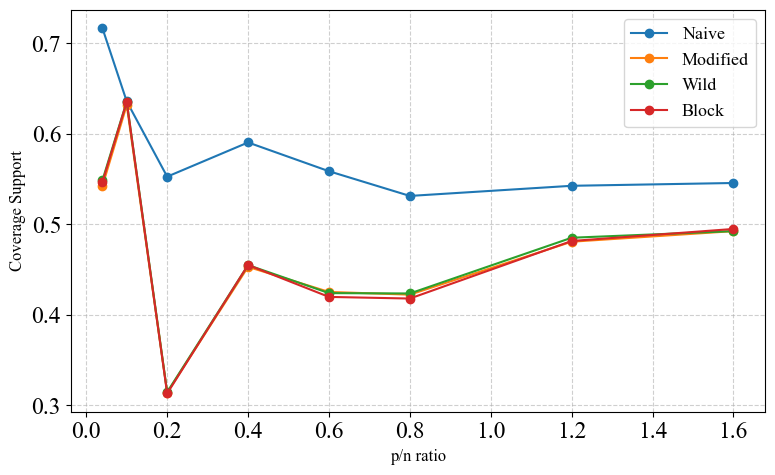

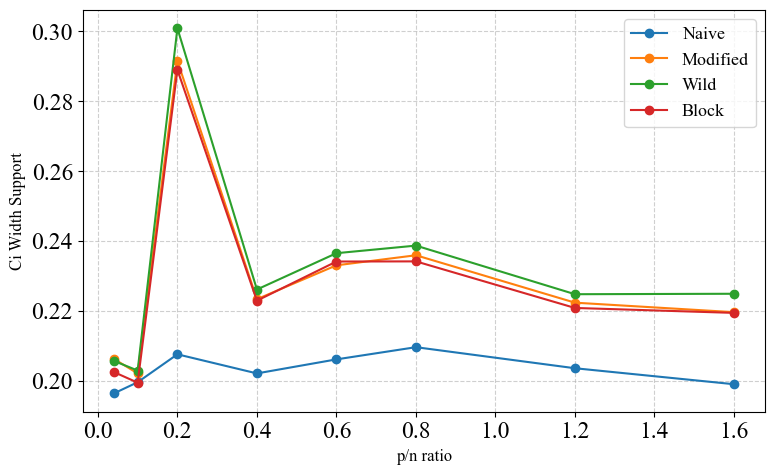

In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cell 1: “Academic” Matplotlib style without LaTeX
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # Use serif font family (no usetex)
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Palatino', 'serif'],
    # Font sizes
    'font.size': 15,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 17,
    'ytick.labelsize': 17,
    'legend.fontsize': 13,
    # Grid style
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    # Figure size
    'figure.figsize': (8, 5),
    # Line/marker
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
})


# Cell 1: helper function to plot metric vs p/n ratio
def plot_metric_vs_pn(base_dir, error, signal, metric,
                      methods=None, p_list=None, n=250):
    """
    Plot the given metric vs p/n ratio for multiple methods.
    
    Parameters:
        base_dir (str): root of results e.g. "results/dimensionality_sensitivity"
        error (str): error type folder
        signal (str): signal type folder
        metric (str): column name in summary.csv to plot (e.g., "coverage_support" or "ci_width_support")
        methods (list): list of method names; defaults to ["naive","modified","wild","block"]
        p_list (list): list of p values to include; defaults to sorted p subfolders found
        n (int): sample size to compute p/n ratio; default=250
    """
    if methods is None:
        methods = ["naive", "modified", "wild", "block"]
    # autodetect p_list if not provided
    if p_list is None:
        # find p subdirs in one method
        example_method = methods[0]
        base_path = os.path.join(base_dir, error, signal, example_method)
        p_list = sorted(int(d.replace("p","")) 
                        for d in os.listdir(base_path) 
                        if d.startswith("p") and os.path.isdir(os.path.join(base_path, d)))
    
    plt.figure(figsize=(8, 5))
    for method in methods:
        metric_vals = []
        pn_vals = []
        for p in p_list:
            summary_path = os.path.join(base_dir, error, signal, method, f"p{p}", "summary.csv")
            if not os.path.isfile(summary_path):
                continue
            df = pd.read_csv(summary_path)
            if metric not in df.columns:
                continue
            metric_vals.append(df.loc[0, metric])
            pn_vals.append(p / n)
        if metric_vals:
            plt.plot(pn_vals, metric_vals, marker='o', label=method.capitalize())
    
    plt.xlabel("p/n ratio")
    plt.ylabel(metric.replace('_', ' ').title())
    # plt.title(f"{metric.replace('_', ' ').title()} vs p/n\n{signal.capitalize()} signal, {error} errors")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"results/dim_sens_figs/{error}_{signal}_{metric}.png")
    plt.show()

# Cell 2: specify case and plot
base_dir    = "results/dimensionality_sensitivity"
error_type  = "ar1"
signal_type = "nearzero"
p_values    = [10, 25, 50, 100, 150, 200, 300, 400]  # specify the grid you ran
n_value     = 250

# Plot coverage vs p/n
plot_metric_vs_pn(base_dir, error_type, signal_type,
                  metric="coverage_support",
                  p_list=p_values, n=n_value)

# Plot CI width vs p/n
plot_metric_vs_pn(base_dir, error_type, signal_type,
                  metric="ci_width_support",
                  p_list=p_values, n=n_value)

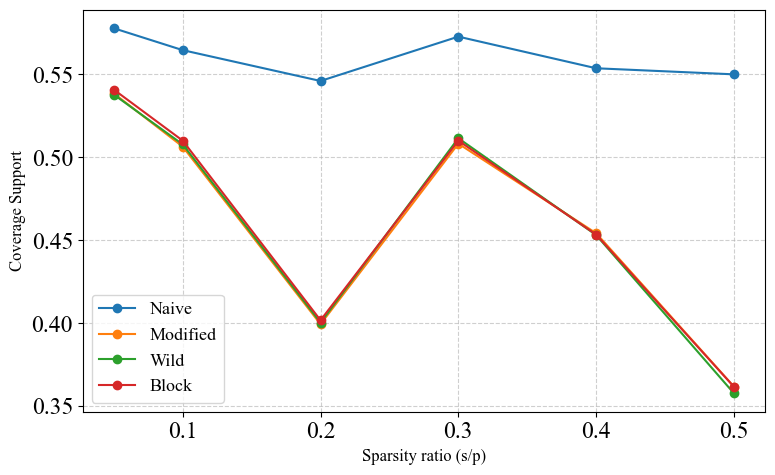

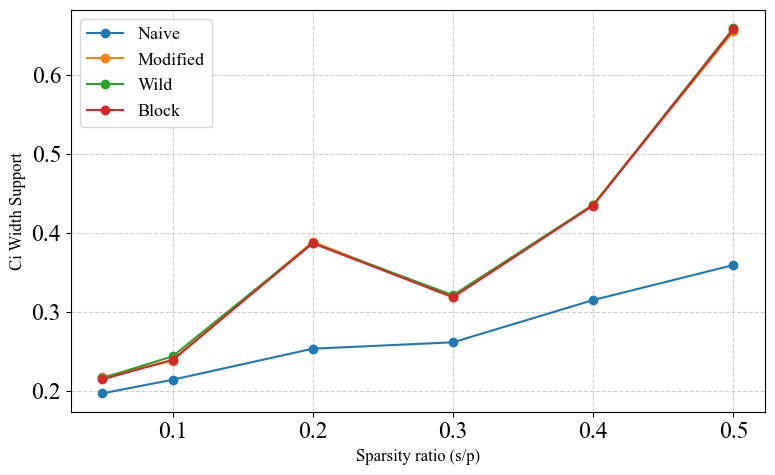

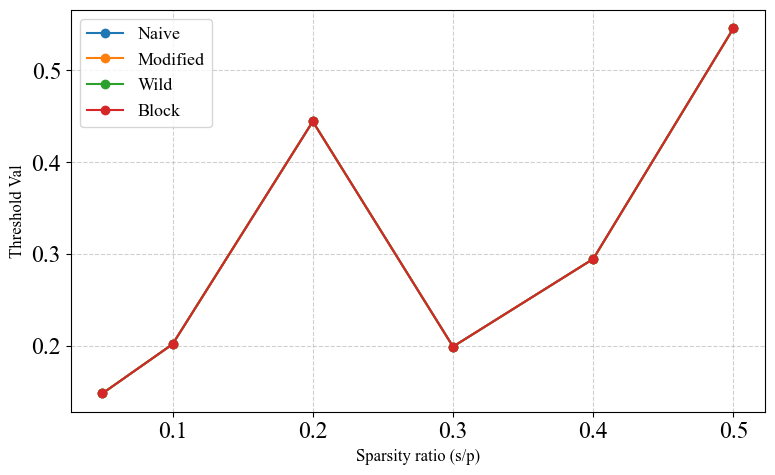

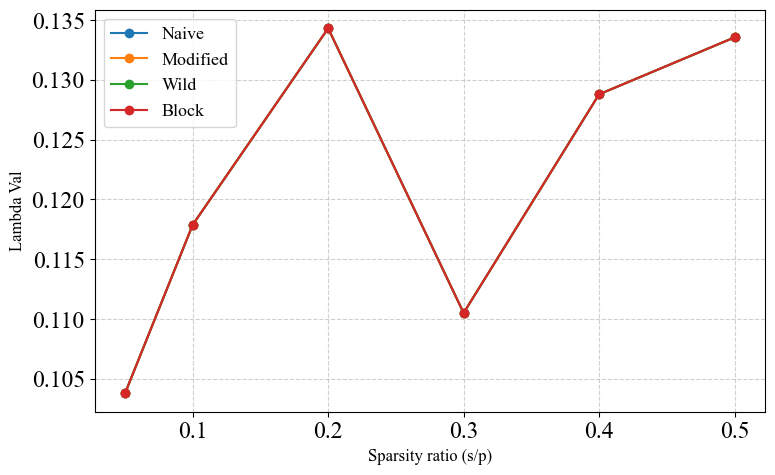

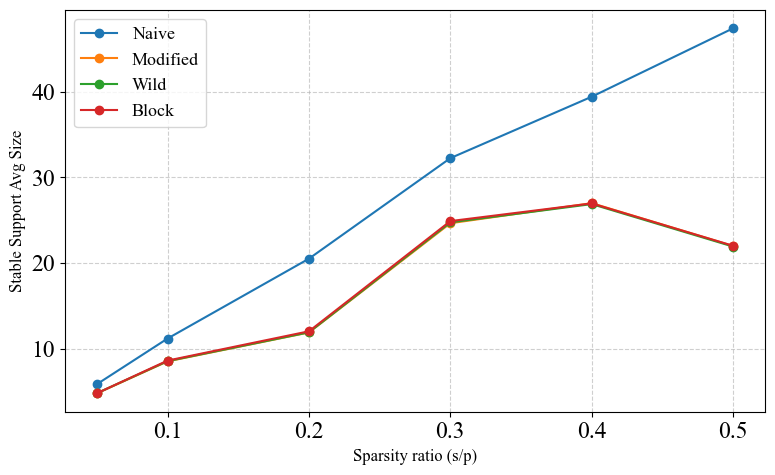

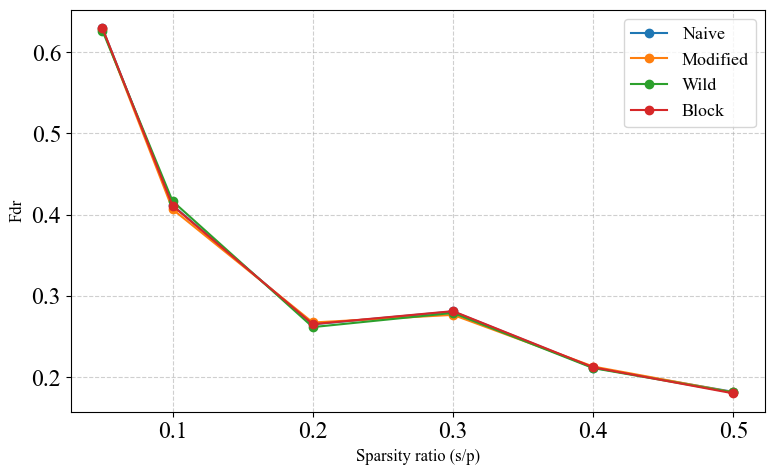

In [54]:
import os
import pandas as pd
import matplotlib.pyplot as plt


mpl.rcParams.update({
    # Use serif font family (no usetex)
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Palatino', 'serif'],
    # Font sizes
    'font.size': 15,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 17,
    'ytick.labelsize': 17,
    'legend.fontsize': 13,
    # Grid style
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    # Figure size
    'figure.figsize': (8, 5),
    # Line/marker
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
})


def plot_metric_vs_sp(base_dir, error, signal, metric,
                      methods=None, s_list=None, p=200):
    if methods is None:
        methods = ["naive", "modified", "wild", "block"]

    # autodetect s_list
    example_dir = os.path.join(base_dir, error, signal, methods[0])
    s_list = sorted(int(d.replace("s","")) 
                    for d in os.listdir(example_dir) 
                    if d.startswith("s") and 
                       os.path.isdir(os.path.join(example_dir, d)))

    plt.figure(figsize=(8,5))
    for method in methods:
        ratios, vals = [], []
        for s in s_list:
            folder = os.path.join(base_dir, error, signal, method, f"s{s}", f"p{p}")
            if not os.path.isdir(folder):
                continue

            # find any file starting with 'summary'
            summary_file = None
            for fn in os.listdir(folder):
                if fn.lower().startswith("summary"):
                    summary_file = os.path.join(folder, fn)
                    break
            if summary_file is None:
                continue

            # read it (csv or excel)
            if summary_file.lower().endswith(".csv"):
                df = pd.read_csv(summary_file)
            else:
                df = pd.read_excel(summary_file)

            if metric not in df.columns:
                continue

            ratios.append(s/p)
            vals.append(df.at[0, metric])

        if vals:
            plt.plot(ratios, vals, marker='o', label=method.capitalize())

    plt.xlabel("Sparsity ratio (s/p)")
    plt.ylabel(metric.replace("_"," ").title())
    # plt.title(f"{signal.capitalize()}, {error} — {metric.replace('_',' ').title()} vs s/p")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    out_dir = os.path.join(base_dir, "figures")
    os.makedirs(out_dir, exist_ok=True)
    if error == "heteroskedastic":
        error = "hetero"
    if metric == "coverage_support":
        metric = "coverage"
    if metric == "ci_width_support":
        metric = "ci_width"
    if metric == "threshold_val":
        metric = "alpha"
    if metric == "lambda_val":
        metric = "lambda"
    if metric == "stable_support_avg_size":
        metric = "avg_support"
    if metric == "fdr":
        metric = "fdr"

    plt.savefig(os.path.join(out_dir, f"{error}_{signal}_{metric}_sparsity.png"))
    plt.show()


# Usage
base_dir    = r"C:\Users\ptboe\vscode\VU\Bootstrapping-Thesis\results\sparsity_sensitivity"
error_type  = "ar1"
signal_type = "nearzero"
p_fixed     = 200

plot_metric_vs_sp(base_dir, error_type, signal_type, "coverage_support", p=p_fixed)
plot_metric_vs_sp(base_dir, error_type, signal_type, "ci_width_support",  p=p_fixed)
plot_metric_vs_sp(base_dir, error_type, signal_type, "threshold_val",  p=p_fixed)
plot_metric_vs_sp(base_dir, error_type, signal_type, "lambda_val",  p=p_fixed)
plot_metric_vs_sp(base_dir, error_type, signal_type, "stable_support_avg_size",  p=p_fixed)
plot_metric_vs_sp(base_dir, error_type, signal_type, "fdr",  p=p_fixed)